In [1]:
from lbg_forecast.likelihood import Likelihood
import numpy as np
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import lbg_forecast.angular_power as ap
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

path = "./"
lhood_mismatch_int = Likelihood(path, override_seed=100, no_noise=False)
#lhood_mismatch_int_2 = Likelihood(path, override_seed=200)
#lhood_mismatch_int_3 = Likelihood(path, override_seed=300)
#lhood_mismatch_int_4 = Likelihood(path, override_seed=400)

#lhood_mismatch_nag = Likelihood(path, mismatch_nag=True)

Initialising likelihood
Initialisation Complete


In [48]:
def auto_all(mu):
    mu = mu.at[800:800*2].set(0.0)
    mu = mu.at[800*2:800*3].set(0.0)
    mu = mu.at[800*3:800*4].set(0.0)
    mu = mu.at[800*5:800*6].set(0.0)
    mu = mu.at[800*6:800*7].set(0.0)
    mu = mu.at[800*8:800*9].set(0.0)
    return mu

def auto_lens(mu):
    mu = mu.at[800*0:800*1].set(0.0)
    mu = mu.at[800*1:800*2].set(0.0)
    mu = mu.at[800*2:800*3].set(0.0)
    mu = mu.at[800*3:800*4].set(0.0)
    mu = mu.at[800*4:800*5].set(0.0)
    mu = mu.at[800*5:800*6].set(0.0)
    mu = mu.at[800*6:800*7].set(0.0)
    mu = mu.at[800*7:800*8].set(0.0)
    mu = mu.at[800*8:800*9].set(0.0)
    return mu

def cross_lens(mu):
    mu = mu.at[800*0:800*1].set(0.0)
    mu = mu.at[800*1:800*2].set(0.0)
    mu = mu.at[800*2:800*3].set(0.0)
    mu = mu.at[800*4:800*5].set(0.0)
    mu = mu.at[800*5:800*6].set(0.0)
    mu = mu.at[800*7:800*8].set(0.0)
    mu = mu.at[800*9:800*10].set(0.0)
    return mu

def cross_lens_u(mu):
    mu = mu.at[800*0:800*1].set(0.0)
    mu = mu.at[800*1:800*2].set(0.0)
    mu = mu.at[800*2:800*3].set(0.0)
    mu = mu.at[800*4:800*5].set(0.0)
    mu = mu.at[800*5:800*6].set(0.0)
    mu = mu.at[800*6:800*7].set(0.0)
    mu = mu.at[800*7:800*8].set(0.0)
    mu = mu.at[800*8:800*9].set(0.0)
    mu = mu.at[800*9:800*10].set(0.0)
    return mu

def cross_lens_g(mu):
    mu = mu.at[800*0:800*1].set(0.0)
    mu = mu.at[800*1:800*2].set(0.0)
    mu = mu.at[800*2:800*3].set(0.0)
    mu = mu.at[800*3:800*4].set(0.0)
    mu = mu.at[800*4:800*5].set(0.0)
    mu = mu.at[800*5:800*6].set(0.0)
    mu = mu.at[800*7:800*8].set(0.0)
    mu = mu.at[800*8:800*9].set(0.0)
    mu = mu.at[800*9:800*10].set(0.0)
    return mu

def cross_lens_r(mu):
    mu = mu.at[800*0:800*1].set(0.0)
    mu = mu.at[800*1:800*2].set(0.0)
    mu = mu.at[800*2:800*3].set(0.0)
    mu = mu.at[800*3:800*4].set(0.0)
    mu = mu.at[800*4:800*5].set(0.0)
    mu = mu.at[800*5:800*6].set(0.0)
    mu = mu.at[800*6:800*7].set(0.0)
    mu = mu.at[800*7:800*8].set(0.0)
    mu = mu.at[800*9:800*10].set(0.0)
    return mu

def auto_clus(mu):
    mu = mu.at[800:800*2].set(0.0)
    mu = mu.at[800*2:800*3].set(0.0)
    mu = mu.at[800*3:800*4].set(0.0)
    mu = mu.at[800*5:800*6].set(0.0)
    mu = mu.at[800*6:800*7].set(0.0)
    mu = mu.at[800*8:800*9].set(0.0)
    mu = mu.at[800*9:800*10].set(0.0)
    return mu

def cross_clus(mu):
    mu = mu.at[800*0:800*1].set(0.0)
    mu = mu.at[800*3:800*4].set(0.0)
    mu = mu.at[800*4:800*5].set(0.0)
    mu = mu.at[800*6:800*7].set(0.0)
    mu = mu.at[800*7:800*8].set(0.0)
    mu = mu.at[800*8:800*9].set(0.0)
    mu = mu.at[800*9:800*10].set(0.0)
    return mu

def log_lhood(params, red, lhood, cut=None):

    if((params < 0).any()):
        return -1e100
    else:
        if cut is not None:
            mu = cut(lhood.mu_vec(params, red))
            d = cut(lhood.cl_mean)
        else:
            mu = lhood.mu_vec(params, red)
            d = lhood.cl_mean
        inv_cov = lhood._inv_C

        #value = -(dim/2)*np.log(2*np.pi) -(dim/2)*lhood.det_C -0.5*(d - mu)@inv_cov@(d - mu).T
        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -1e100
        else:
            return value

@jax.jit        
def nll_jax(params):

    lhood=lhood_mismatch_int
    red=1.0

    mu = lhood.mu_vec(params, red)
    d = lhood.cl_mean
    inv_cov = lhood._inv_C
    value = -0.5*(d - mu)@inv_cov@(d - mu).T
    return -1.0*value

        
fid_params = np.array([lhood_mismatch_int._cosmo_fid.sigma8, 
                    lhood_mismatch_int._cosmo_fid.Omega_c, lhood_mismatch_int._cosmo_fid.Omega_b,
                    lhood_mismatch_int._cosmo_fid.h, lhood_mismatch_int._cosmo_fid.n_s,
                    lhood_mismatch_int._b_lbg_u, lhood_mismatch_int._b_lbg_g, lhood_mismatch_int._b_lbg_r])

/var/folders/s9/j1tshp4s5019kbkk8hz2q9840000gn/T/ipykernel_17601/3427446652.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{tick:.0f}$\sigma$" for tick in yticks])


[Text(0, -10.0, '-10$\\sigma$'),
 Text(0, -7.5, '-8$\\sigma$'),
 Text(0, -5.0, '-5$\\sigma$'),
 Text(0, -2.5, '-2$\\sigma$'),
 Text(0, 0.0, '0$\\sigma$'),
 Text(0, 2.5, '2$\\sigma$'),
 Text(0, 5.0, '5$\\sigma$'),
 Text(0, 7.5, '8$\\sigma$'),
 Text(0, 10.0, '10$\\sigma$')]

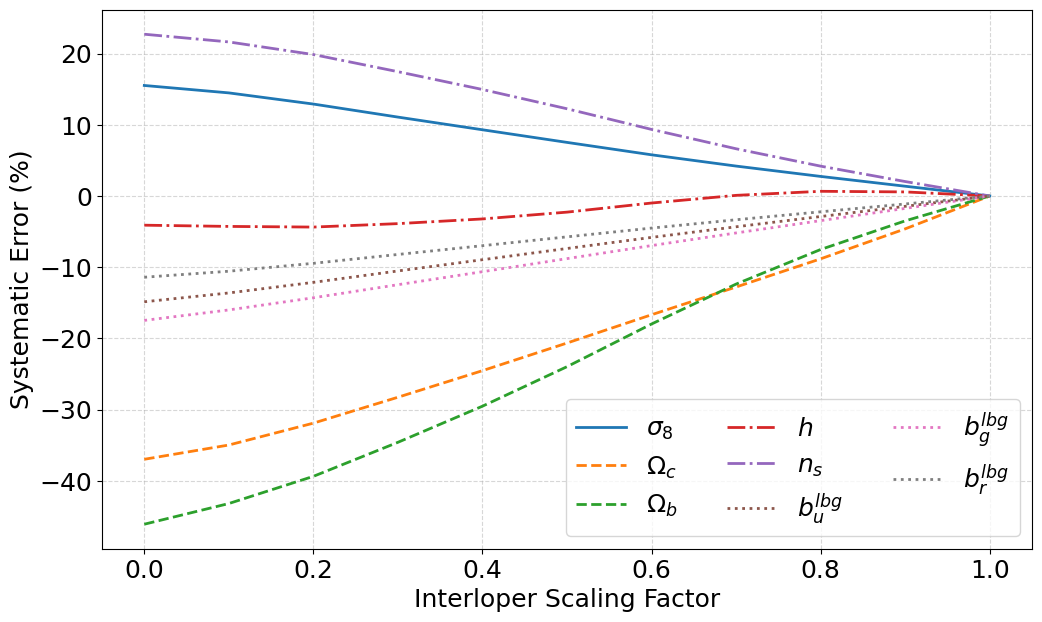

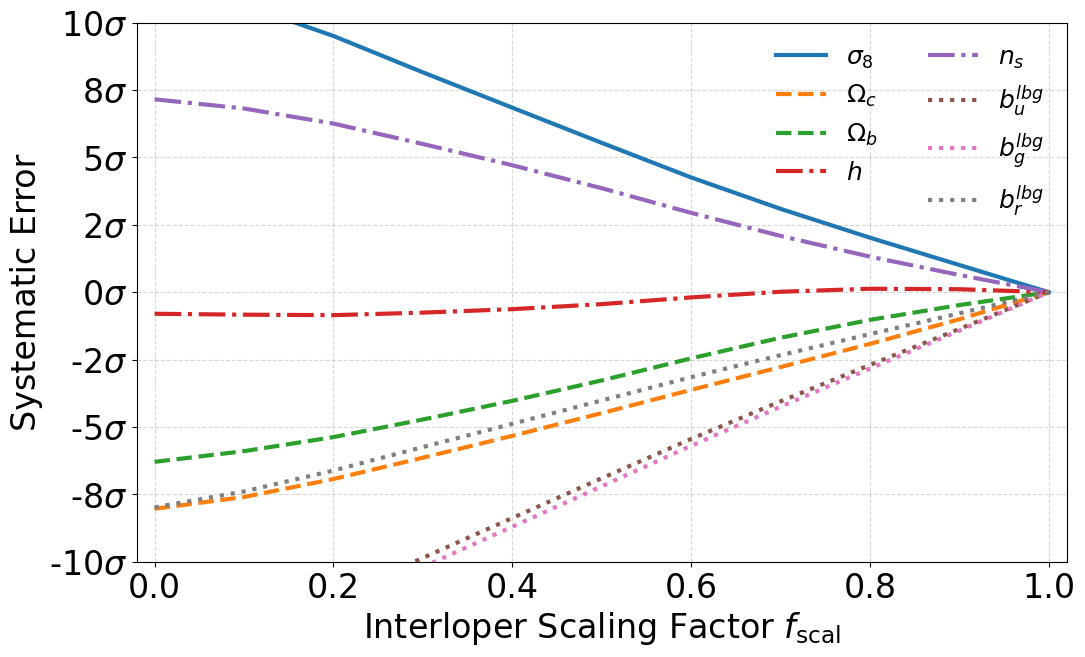

In [67]:
opt_params = np.array([[0.94200405, 0.16486708, 0.02563145, 0.64371086, 1.19549782, 0.63963092, 0.66078972, 0.74091275], #(0.0)
                        [0.93350671, 0.17010985, 0.02701332, 0.64255139, 1.18494721, 0.64896143, 0.67255456, 0.74797387], #(0.1)
                        [0.92072021, 0.17814233, 0.02882784, 0.64193418, 1.16768378, 0.66012983, 0.68624047, 0.75726135], #(0.2)
                        [0.90578971, 0.18766118, 0.03110113, 0.6451801,  1.14424245, 0.67215277, 0.70092487, 0.76766414], #(0.3)
                        [0.89127144, 0.19742162, 0.03351321, 0.64960107, 1.11987398, 0.68401525, 0.71554667, 0.77797132], #(0.4)
                        [0.87681155, 0.20757524, 0.0361515, 0.65601623, 1.09350979, 0.69585473, 0.73024831, 0.78834429], #(0.5)
                        [0.86260719, 0.2179637,  0.03900089, 0.66460561, 1.0652545,  0.70756854, 0.74492643, 0.79866395], #(0.6)
                        [0.84969711, 0.22815456, 0.04166668, 0.67183561, 1.03878702, 0.71875939, 0.75912153, 0.80842033], #(0.7)
                        [0.83785232, 0.23850734, 0.04397535, 0.67565304, 1.01500295, 0.72959261, 0.77297111, 0.81776251], #(0.8)
                        [0.82662772, 0.24951132, 0.04588741, 0.67507093, 0.99395419, 0.74033164, 0.78672731, 0.82696607], #(0.9)
                        [0.81545297, 0.2615883,  0.047548,   0.67123726, 0.97419833, 0.75124437, 0.80067268, 0.83633743]]) #(1.0)

F=np.load('fisher_data/fisher.npy')
F_marg=np.load('fisher_data/fisher_marg.npy')

stds = np.sqrt(np.diagonal(np.linalg.inv(F)))
marg_stds = np.sqrt(np.diagonal(np.linalg.inv(F_marg)))

labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$"])
lss = ['-', "--", "--","-.", "-.", ":", ":", ":"]
init = fid_params
grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
f, ax = plt.subplots(1, 1, figsize=(12, 7))


for param in range(fid_params.shape[0]):
    ax.plot(grid, 100*(opt_params[:, param]-opt_params[-1, param])/opt_params[-1, param], label=labels[param], ls=lss[param], lw=2)
ax.legend(ncols=3, fontsize=18)
fs=18

ax.grid(alpha=0.5, ls='--')
#ax.set_xlim(-0.02, 1.02)
#ax.set_ylim(-10.2, 20.2)
ax.set_ylabel('Systematic Error (%)', fontsize=fs)
ax.set_xlabel('Interloper Scaling Factor', fontsize=fs)
ax.tick_params('x', labelsize=fs)
ax.tick_params('y', labelsize=fs)

f2, ax2 = plt.subplots(1, 1, figsize=(12, 7))


for param in range(fid_params.shape[0]):
    ax2.plot(grid, (opt_params[:, param]-opt_params[-1, param])/marg_stds[param], label=labels[param], ls=lss[param], lw=3)
ax2.legend(ncols=2, fontsize=18, frameon=False)
fs=24

ax2.grid(alpha=0.5, ls='--')
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-10, 10)
ax2.set_ylabel('Systematic Error', fontsize=fs)
ax2.set_xlabel('Interloper Scaling Factor $f_{\mathrm{scal}}$', fontsize=fs)
ax2.tick_params('x', labelsize=fs)
ax2.tick_params('y', labelsize=fs)

yticks = plt.gca().get_yticks()
# Set new tick labels with σ
plt.gca().set_yticklabels([f"{tick:.0f}$\sigma$" for tick in yticks])


In [51]:
#(2.0*nll_jax(jnp.array([0.93923863, 0.16578732, 0.02608145, 0.65053266, 1.18721659, 0.64054374, 0.66179601, 0.74205008])))/8000

(2.0*nll_jax(jnp.array([0.82662772, 0.24951132, 0.04588741, 0.67507093, 0.99395419, 0.74033164, 0.78672731, 0.82696607])))/8000

Array(1.02741508, dtype=float64)

In [ ]:
# Initialize parameters
mu_i = jnp.array([0.93923863, 0.16578732, 0.02608145, 0.65053266, 1.18721659, 0.64054374, 0.66179601, 0.74205008])

# Build optimizer (Adam)
optimizer = optax.adam(learning_rate=1e-2)
opt_state = optimizer.init(mu_i)

# Define one optimization step
def step(mu_i, opt_state):
    loss, grads = jax.value_and_grad(nll_jax)(mu_i)
    updates, opt_state = optimizer.update(grads, opt_state)
    mu_i = optax.apply_updates(mu_i, updates)
    return mu_i, opt_state, loss

# Run optimization loop
for i in range(5000):
    mu_i, opt_state, loss = step(mu_i, opt_state)
    #if i % 100 == 0:
    print(f"Step {i:4d} | mu={mu_i} | loss={loss:.4f}")

print("\nEstimated parameters:")
print(mu_i)

Step    0 | mu=[0.94923863 0.15578732 0.03608145 0.64053266 1.19721659 0.65054374
 0.67179601 0.75205008] | loss=4276.2937
Step    1 | mu=[0.9418041  0.16322537 0.02864291 0.6479679  1.20465983 0.64310476
 0.66435712 0.7446107 ] | loss=5188.5084
Step    2 | mu=[0.93551532 0.16960436 0.02239461 0.65416983 1.2108757  0.63659716
 0.65794338 0.73828558] | loss=4289.4358
Step    3 | mu=[0.93393956 0.17427729 0.02051055 0.65568587 1.21236247 0.6346184
 0.6559591  0.73659199] | loss=4613.8865
Step    4 | mu=[0.93563765 0.17598304 0.02169276 0.65378021 1.21049084 0.63612088
 0.65739495 0.73833516] | loss=4862.4970
Step    5 | mu=[0.93885045 0.17418802 0.02432344 0.65010754 1.20694759 0.63938091
 0.66062393 0.74181923] | loss=4674.6416
Step    6 | mu=[0.94225962 0.1700368  0.0271765  0.64585701 1.20295319 0.64308654
 0.66440726 0.74577257] | loss=4398.9764
Step    7 | mu=[0.94464225 0.16471115 0.02914775 0.64217071 1.19967801 0.64596133
 0.66753389 0.74893091] | loss=4312.5614
Step    8 | mu=[0

KeyboardInterrupt: 

In [4]:
from scipy.optimize import minimize

bounds = [(0., 100.), 
          (0., 1.),
          (0., 1.),
          (0., 1.),
          (0., 100.),
          (0., 100.),
          (0., 100.),
          (0., 100.)] 


for index, lhood in enumerate([lhood_mismatch_int]):
    reduced_list=np.linspace(0.0, 1.0, 21)
    print(reduced_list)
    results = []
    p_diffs = []
    for reduced in reduced_list: 
        print(reduced)
        res = minimize(lambda x, y=reduced, l=lhood: -log_lhood(x, y, l), fid_params, bounds=bounds, method='Nelder-Mead')
        #res = basinhopping(lambda x, y=reduced, l=lhood: -log_lhood(x, y, l), fid_params)

        print(res.success)
        p_diffs.append(((res.x - fid_params)/fid_params)*100)
        results.append(res.x)
        print(res.x)

    np.save('biases/results_'+str(index)+'_intbinc.npy', results)
    np.save('biases/pdiffs_'+str(index)+'_intbinc.npy', p_diffs)
    np.save('biases/grid_'+str(index)+'_intbinc.npy', reduced_list)


[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
0.0
True
[0.88296381 0.16927662 0.0493246  0.99963738 0.95972512 0.65490744
 0.67865487 0.76274184]
0.05
True
[0.88139284 0.17044847 0.05013324 0.99901052 0.95985566 0.65897269
 0.68384898 0.76540357]
0.1
True
[0.88390676 0.17939804 0.04501209 0.86482289 1.01272559 0.6643943
 0.68987525 0.76858599]
0.15000000000000002
True
[0.87914447 0.18544807 0.04391838 0.83711487 1.01177272 0.66990925
 0.69666698 0.77286425]
0.2
True
[0.91644415 0.1804092  0.02944636 0.64561867 1.15948595 0.66194931
 0.68809525 0.75939728]
0.25
True
[0.87600925 0.19285115 0.04289787 0.783685   1.03216611 0.67888336
 0.70778565 0.77899483]
0.30000000000000004
True
[0.8699828  0.17863844 0.05281893 0.99998585 0.93656448 0.67747779
 0.70901012 0.77800937]
0.35000000000000003
True
[0.86644286 0.1961435  0.04681642 0.82280244 0.99847932 0.68738096
 0.7193026  0.78582514]
0.4
True
[0.86266762 0.20097434 0.04665151 

8537.44854437699 3200.74707724681 3155.348816171967 1446.4067012612559 4954.43869503086 1853.9064336466208 1669.0622228789189 1315.2583864243225
8490.982944581388 3187.7140636480303 3154.468268584751 1440.7902263907986 4877.644852720089 1821.123181053003 1632.9658136087676 1313.6677432104802
8480.635934789381 3203.6446916647897 3152.8829069331614 1439.3079607224902 4854.0798033985375 1813.4794374930896 1613.9548677691353 1320.7706848708103
8441.288658703554 3188.856772657011 3151.6232520607136 1431.3153824340327 4795.566273899007 1787.8334660320695 1585.7138680279866 1320.1841001027597
8386.48881895121 3159.194333720227 3151.6421381120995 1438.7624936886125 4701.754005068054 1761.4602879522017 1524.8323013692868 1318.8469238829503
8367.179152468658 3163.1400655772864 3149.785640056606 1420.7810187968144 4690.0256727824135 1743.49081559763 1534.164522010807 1318.2131707411522
8309.148865497687 3148.365110285046 3151.5779747207976 1406.2034831207434 4580.638154633376 1700.570380558524 14

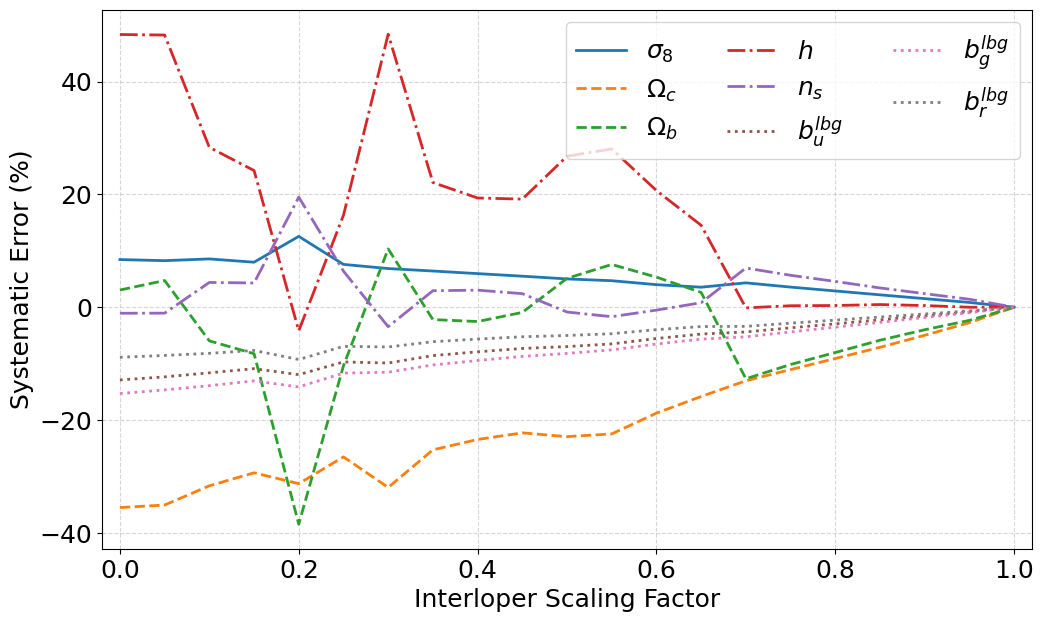

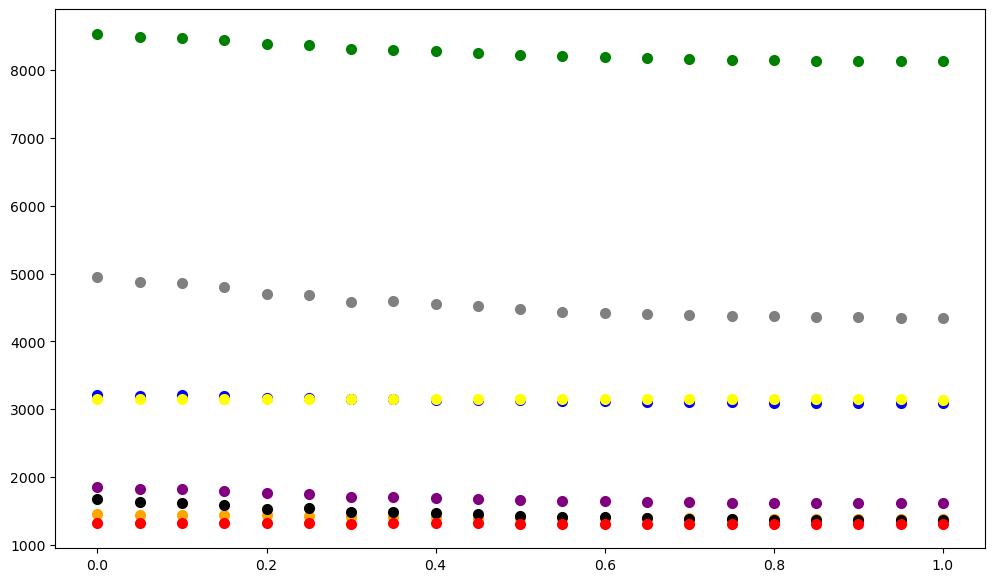

In [5]:
loaded_results = np.load('biases/results_0_intbinc.npy')
loaded_pdiffs = np.load('biases/pdiffs_0_intbinc.npy')
loaded_grid = np.load('biases/grid_0_intbinc.npy')

labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$"])
lss = ['-', "--", "--","-.", "-.", ":", ":", ":"]
init = loaded_results[-1, :]

f, ax = plt.subplots(1, 1, figsize=(12, 7))


for param in range(fid_params.shape[0]):
    ax.plot(loaded_grid, 100*(loaded_results[:, param] - loaded_results[-1, param])/loaded_results[-1, param], label=labels[param], ls=lss[param], lw=2)
ax.legend(ncols=3, fontsize=18)
fs=18

ax.grid(alpha=0.5, ls='--')
ax.set_xlim(-0.02, 1.02)
#ax.set_ylim(-10.2, 20.2)
ax.set_ylabel('Systematic Error (%)', fontsize=fs)
ax.set_xlabel('Interloper Scaling Factor', fontsize=fs)
ax.tick_params('x', labelsize=fs)
ax.tick_params('y', labelsize=fs)


f2, ax2 = plt.subplots(1, 1, figsize=(12, 7))

for result in range(loaded_results.shape[0]):

    tot= -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=None)
    auto_clustering = -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=auto_clus)
    cross_clustering = -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=cross_clus)
    auto_lensing = -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=auto_lens)
    cross_lensing = -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=cross_lens)

    cross_lensing_u = -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=cross_lens_u)
    cross_lensing_g = -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=cross_lens_g)
    cross_lensing_r = -2.*log_lhood(loaded_results[result, :], loaded_grid[result], lhood_mismatch_int, cut=cross_lens_r)

    print(tot, auto_clustering, cross_clustering, auto_lensing, cross_lensing, cross_lensing_u, cross_lensing_g, cross_lensing_r)
    ax2.scatter(loaded_grid[result], auto_clustering, lw=2, color='blue')
    ax2.scatter(loaded_grid[result], cross_clustering, lw=2, color='yellow')
    ax2.scatter(loaded_grid[result], auto_lensing, lw=2, color='orange')
    ax2.scatter(loaded_grid[result], cross_lensing, lw=2, color='grey')

    ax2.scatter(loaded_grid[result], cross_lensing_u, lw=2, color='purple')
    ax2.scatter(loaded_grid[result], cross_lensing_g, lw=2, color='black')
    ax2.scatter(loaded_grid[result], cross_lensing_r, lw=2, color='red')

    ax2.scatter(loaded_grid[result], tot, lw=2, color='green')




In [6]:
-2*log_lhood(loaded_results[0, :], 0.0, lhood_mismatch_int, cut=None), -2*log_lhood(loaded_results[1, :], 0.0, lhood_mismatch_int, cut=None)

(Array(8537.44854438, dtype=float64), Array(8569.09491991, dtype=float64))

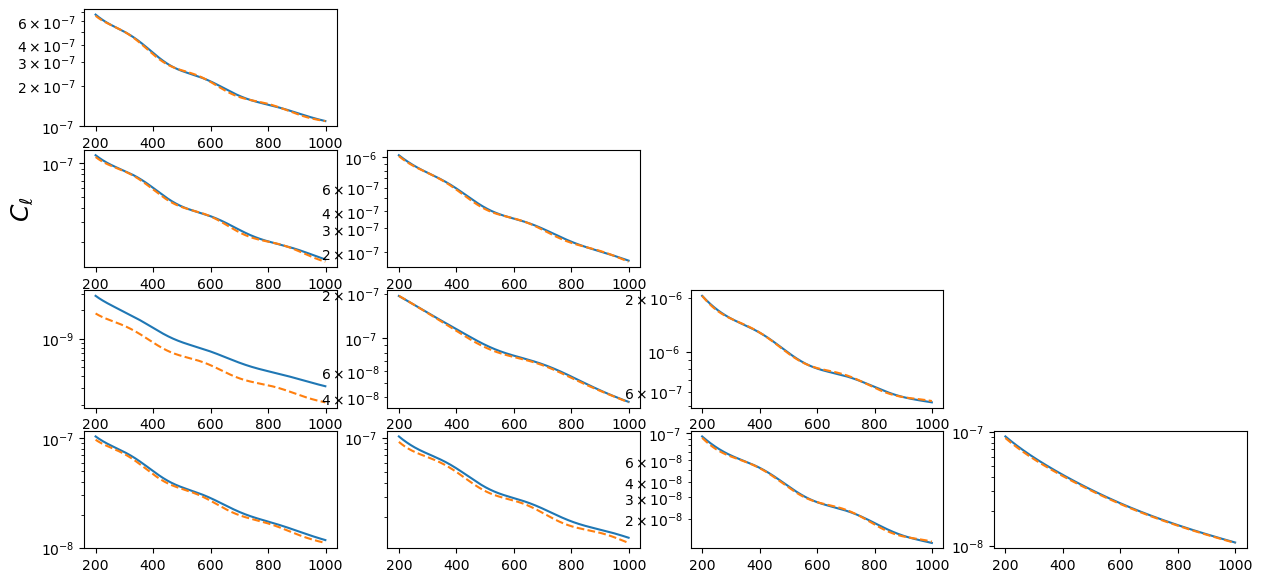

In [ ]:
mu = lhood_mismatch_int.mu_vec(fid_params, 0.0)
mu_0 = lhood_mismatch_int.mu_vec(fid_params, 1.0)
mu_x = lhood_mismatch_int.mu_vec(loaded_results[0], 0.0)
#mu_01 = lhood_mismatch_int.mu_vec(loaded_results[-1], 1.0)
d = lhood_mismatch_int.cl_mean

ap.compare_cls(mu_0, mu_x, lhood_mismatch_int._ell, (15, 7), 18, 4)


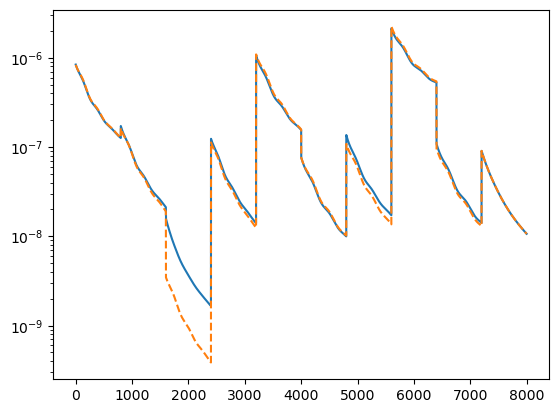

In [81]:
plt.plot(lhood_mismatch_int.mu_vec(fid_params, 1.0))
plt.plot(lhood_mismatch_int.mu_vec(fid_params, 0.0), ls='--')


#plt.plot(lhood_mismatch_int.mu_vec(loaded_results[0, :], 0.0), ls='--')

#plt.plot(lhood_mismatch_int.cl_mean, ls='--', color='k')
plt.yscale('log')

In [ ]:
from scipy.optimize import minimize

fid_params = np.array([lhood_mismatch_int._cosmo_fid.sigma8, 
                    lhood_mismatch_int._cosmo_fid.Omega_c, lhood_mismatch_int._cosmo_fid.Omega_b,
                    lhood_mismatch_int._cosmo_fid.h, lhood_mismatch_int._cosmo_fid.n_s,
                    lhood_mismatch_int._b_lbg_u, lhood_mismatch_int._b_lbg_g, lhood_mismatch_int._b_lbg_r])


bounds = [(0, 100.), 
          (0, 1.),
          (0, 1.),
          (0, 1.),
          (0, 100.),
          (0, 100.),
          (0, 100.),
          (0, 100.)] 

def log_lhood_nag(params):

    if((params < 0).any()):
        return -1e100
    else:
        mu = lhood_mismatch_nag.mu_vec_nag(params)
        d = lhood_mismatch_nag.cl_mean
        inv_cov = lhood_mismatch_nag._inv_C

        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -1e100
        else:
            return value


res = minimize(lambda x: -log_lhood_nag(x), fid_params, bounds=bounds, method='Nelder-Mead')
print(res.x, fid_params, res.success, log_lhood_nag(fid_params), log_lhood_nag(res.x))
print('%: ', ((res.x - fid_params)/fid_params)*100)


In [ ]:
mu_x = lhood_mismatch_nag.mu_vec_nag(res.x)
mu_0 = lhood_mismatch_nag.mu_vec_nag(fid_params)
d = lhood_mismatch_nag.cl_mean
ap.compare_cls(d, mu_x, lhood_mismatch_nag._ell, (15, 7), 18, 4)

In [ ]:
plt.plot(lhood_mismatch_nag.cl_mean)
plt.plot(lhood_mismatch_nag.mu_vec_nag(res.x))
plt.plot(lhood_mismatch_nag.mu_vec_nag(fid_params))
plt.plot(lhood_mismatch_int.mu_vec(fid_params, red=1.0))
plt.yscale('log')

import numpy as np
import emcee
import matplotlib.pyplot as plt
import h5py


fid_params = np.array([0.94200405, 0.16486708, 0.02563145, 0.64371086, 1.19549782, 0.63963092, 0.66078972, 0.74091275])

def log_lhood(params):

    if((params < 0.0).any()):
        return -np.inf
    if(params[1]>1.0 or params[2]>1.0 or params[3] > 1.0):
        return -np.inf
    else:
        mu = lhood_mismatch_int.mu_vec(params, red=0.0)
        d = lhood_mismatch_int.cl_mean
        inv_cov = lhood_mismatch_int._inv_C

        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -np.inf
        else:
            return value

ndim = fid_params.shape[0]
nwalkers = 100
nsteps = 5000

# Initialize walkers in a small Gaussian ball around mu
p0 = fid_params + 1e-5 * np.random.randn(nwalkers, ndim)

# Run sampler

filename = "emcee_run_closer_start.h5"
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_lhood, backend=backend)
sampler.run_mcmc(p0, nsteps, progress=True)

# Get chain of samples
samples = sampler.get_chain(discard=0, flat=True)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.5)
plt.xlabel("theta[0]")
plt.ylabel("theta[1]")
plt.title("emcee MCMC samples")
plt.show()